# 02 Model Training and High-Recall Evaluation

This notebook summarizes the final model training and evaluation outputs. It does not retrain the models; instead, it reads the saved manifest, final metric tables, and threshold tables produced by the reproducible training script.

The goal is to compare four model families, Random Forest, XGBoost, MLP, and LSTM, under the same 5-fold incident-window protocol. The comparison is framed around high-recall traffic incident detection. Recall is prioritized because missing incidents is operationally costly, while false positives are handled later through explanation and alarm triage.

This notebook should help justify the modelling stage in the report: which models were trained, which folds were completed, how thresholds were selected, and how the final results should be interpreted without turning the project into only a model-performance competition.


## Load Final Training Tables

The training script saves metrics, thresholds, and the final manifest. This notebook reads those files instead of retraining models.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif not (PROJECT_ROOT / "nita_xai").exists():
    PROJECT_ROOT = next(p for p in PROJECT_ROOT.parents if (p / "nita_xai").exists())

sys.path.insert(0, str(PROJECT_ROOT))
from nita_xai import config

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

import json

metrics = pd.read_csv(config.FINAL_MODEL_METRICS_PATH)
comparison = pd.read_csv(config.FINAL_MODEL_COMPARISON_PATH)
thresholds = pd.read_csv(config.FINAL_THRESHOLDS_PATH)
thesis_metrics = pd.read_csv(config.THESIS_STYLE_MODEL_METRICS_PATH)
manifest = json.loads(config.FINAL_MANIFEST_PATH.read_text(encoding="utf-8"))

print(f"Manifest entries: {len(manifest)}")
print(f"Metric rows: {len(metrics)}")
print(f"Threshold rows: {len(thresholds)}")


Manifest entries: 20
Metric rows: 20
Threshold rows: 20


so 20 manifest entries: 4 models times 5 folds. This confirms the final training output covers all model/fold combinations.


## Final Model Comparison

This table reports the main five-fold metrics. Recall is emphasized because the project is designed around high-recall incident detection.


In [2]:
display_cols = [
    "model_name", "recall_mean", "detection_rate_mean", "precision_mean", "f1_mean",
    "roc_auc_mean", "pr_auc_mean", "true_positives_total", "false_positives_total",
    "missed_incidents_total", "true_negatives_total",
]
comparison[display_cols].sort_values("recall_mean", ascending=False)


,model_name,recall_mean,detection_rate_mean,precision_mean,f1_mean,roc_auc_mean,pr_auc_mean,true_positives_total,false_positives_total,missed_incidents_total,true_negatives_total
2,random_forest,0.747984,0.747984,0.524505,0.615876,0.932524,0.643938,1366,1240,458,20036
3,xgboost,0.733814,0.733814,0.522482,0.609374,0.933941,0.578802,1337,1232,487,20044
1,mlp,0.703802,0.703802,0.513658,0.591556,0.920360,0.612279,1278,1233,546,20043
0,lstm,0.649399,0.649399,0.528795,0.581656,0.902950,0.608259,1184,1061,640,20215


higher recall means more incident timestamps were detected. Precision tells us how many alarms were correct, but low precision is not automatically failure here because the project adds triage support for operator judgment.


## Incident-Level Metrics

The previous table is timestamp-based. For incident detection, an incident is counted as detected if the model raises at least one alarm during the labeled incident period. This gives Detection Rate, False Alarm Rate, and Mean Time to Detection.


In [3]:
thesis_cols = [
    "model", "detection_rate_mean", "false_alarm_rate_mean",
    "mean_time_to_detection_minutes", "incident_count_total",
    "detected_incidents_total", "missed_incidents_total",
    "false_alarm_timestamps_total",
]
thesis_metrics[thesis_cols].sort_values("detection_rate_mean", ascending=False)


,model,detection_rate_mean,false_alarm_rate_mean,mean_time_to_detection_minutes,incident_count_total,detected_incidents_total,missed_incidents_total,false_alarm_timestamps_total
3,xgboost,1.000000,0.057915,1.085714,175,175,0,1232
0,lstm,0.994286,0.049876,0.543697,175,174,1,1061
2,random_forest,0.994286,0.058301,0.685714,175,174,1,1240
1,mlp,0.982857,0.057953,0.724370,175,172,3,1233


this incident-level table is the fairer comparison point. The timestamp-level table remains useful for understanding alarm coverage, but it is stricter and should not be treated as the same metric as thesis Detection Rate.


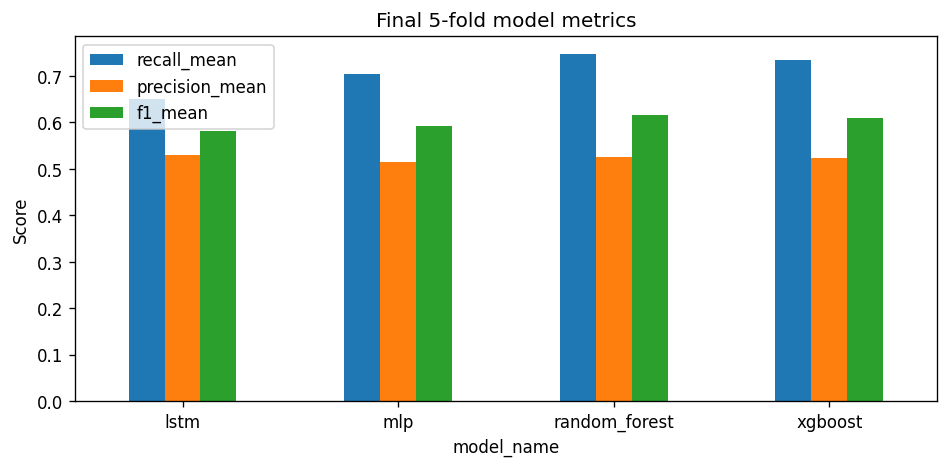

In [4]:
ax = comparison.set_index("model_name")[["recall_mean", "precision_mean", "f1_mean"]].plot(
    kind="bar", figsize=(8, 4), rot=0
)
ax.set_title("Final 5-fold model metrics")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()


## Fold-Level Metrics

Fold-level results show whether one model is stable across different held-out stream groups.


In [5]:
metrics.sort_values(["model_name", "fold"])


,model_name,fold,threshold,precision,recall,f1,roc_auc,pr_auc,tp,fp,fn,tn,train_windows,calibration_windows,test_windows,model_path,score_path,run_mode,threshold_strategy,epochs_trained
0,lstm,1,0.071721,0.549865,0.608955,0.577904,0.886130,0.582683,204,167,131,4118,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_1\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_1\lstm_fold_1_scores.csv,final,baseline_calibration_quantile,29.0
4,lstm,2,0.071195,0.501027,0.668493,0.572770,0.906626,0.600582,244,243,121,4012,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_2\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_2\lstm_fold_2_scores.csv,final,baseline_calibration_quantile,21.0
8,lstm,3,0.070524,0.532558,0.585678,0.557856,0.903606,0.599001,229,201,162,4028,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_3\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_3\lstm_fold_3_scores.csv,final,baseline_calibration_quantile,30.0
12,lstm,4,0.069529,0.503080,0.698006,0.584726,0.903267,0.637311,245,242,106,4027,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_4\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_4\lstm_fold_4_scores.csv,final,baseline_calibration_quantile,18.0
16,lstm,5,0.069746,0.557447,0.685864,0.615023,0.915119,0.621720,262,208,120,4030,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_5\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\lstm\fold_5\lstm_fold_5_scores.csv,final,baseline_calibration_quantile,30.0
1,mlp,1,0.090978,0.582766,0.767164,0.662371,0.942798,0.688721,257,184,78,4101,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\mlp\fold_1\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\mlp\fold_1\mlp_fold_1_scores.csv,final,baseline_calibration_quantile,7.0
5,mlp,2,0.091471,0.495512,0.756164,0.598698,0.939870,0.635697,276,281,89,3974,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\mlp\fold_2\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\mlp\fold_2\mlp_fold_2_scores.csv,final,baseline_calibration_quantile,10.0
9,mlp,3,0.105628,0.503145,0.613811,0.552995,0.917951,0.582774,240,237,151,3992,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\mlp\fold_3\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\mlp\fold_3\mlp_fold_3_scores.csv,final,baseline_calibration_quantile,9.0
13,mlp,4,0.101687,0.445017,0.737892,0.555198,0.922937,0.589273,259,323,92,3946,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\mlp\fold_4\model.pt,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detection-system\nita_xai\models\final\mlp\fold_4\mlp_fold_4_scores.csv,final,baseline_calibration_quantile,7.0
17,mlp,5,0.094011,0.541850,0.643979,0.588517,0.878246,0.564929,246,208,136,4030,320880,80640,4620,C:\Users\Acer\Desktop\BME sem 6\Project Lab\newest\traffic-anomaly-detec

large variation between folds can indicate that some incidents or stations are harder to detect. Those cases are good candidates for XAI inspection.


## High-Recall Thresholds

Thresholds are selected on baseline/calibration data and then applied to held-out test windows. This avoids choosing thresholds directly from the test incidents.


In [6]:
thresholds.sort_values(["model_name", "fold"])


,model_name,fold,threshold,threshold_strategy,run_mode
0,lstm,1,0.071721,baseline_calibration_quantile,final
4,lstm,2,0.071195,baseline_calibration_quantile,final
8,lstm,3,0.070524,baseline_calibration_quantile,final
12,lstm,4,0.069529,baseline_calibration_quantile,final
16,lstm,5,0.069746,baseline_calibration_quantile,final
1,mlp,1,0.090978,baseline_calibration_quantile,final
5,mlp,2,0.091471,baseline_calibration_quantile,final
9,mlp,3,0.105628,baseline_calibration_quantile,final
13,mlp,4,0.101687,baseline_calibration_quantile,final
17,mlp,5,0.094011,baseline_calibration_quantile,final
